In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

In [15]:
import os
for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/kabure/german-credit-data-with-risk/german_credit_data.csv


In [16]:
import pandas as pd
df = pd.read_csv('/kaggle/input/datasets/kabure/german-credit-data-with-risk/german_credit_data.csv')
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


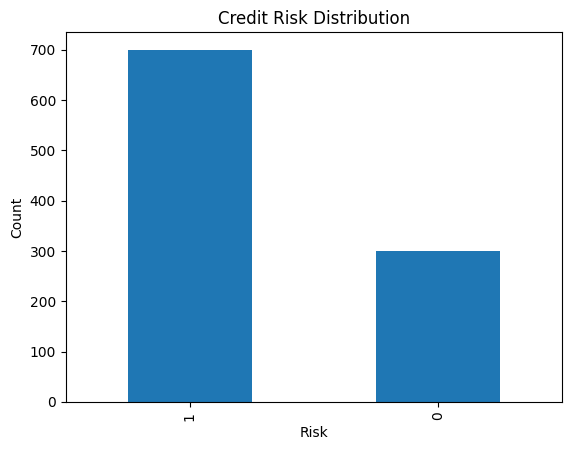

In [40]:
import matplotlib.pyplot as plt
df["Risk"].value_counts().plot(kind="bar")
plt.title("Credit Risk Distribution")
plt.xlabel("Risk")
plt.ylabel("Count")
plt.show()

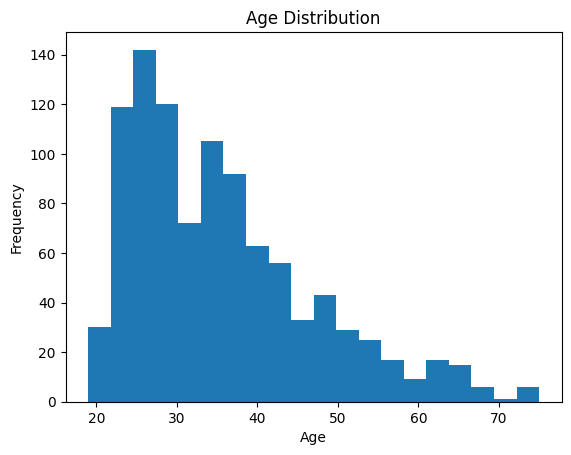

In [41]:
plt.hist(df["Age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

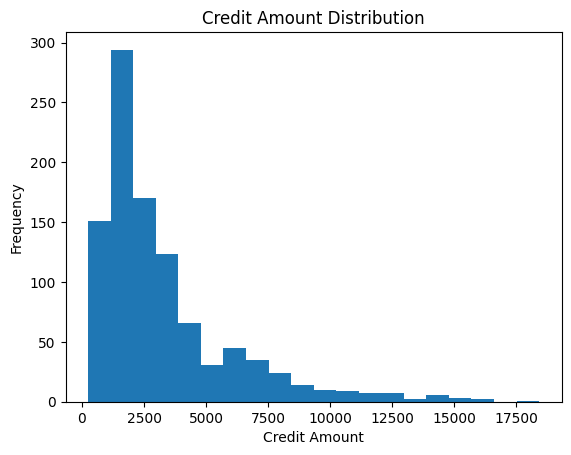

In [42]:
plt.hist(df["Credit amount"], bins=20)
plt.title("Credit Amount Distribution")
plt.xlabel("Credit Amount")
plt.ylabel("Frequency")
plt.show()

In [43]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

In [44]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,1,2,1,4,0,1169,6,5,1
1,22,0,2,1,0,1,5951,48,5,0
2,49,1,1,1,0,3,2096,12,3,1
3,45,1,2,0,0,0,7882,42,4,1
4,53,1,2,0,0,0,4870,24,1,0


In [45]:
X = df.drop("Risk", axis=1)
y = df["Risk"]

In [46]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [47]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [48]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [49]:
from sklearn.metrics import accuracy_score
print("Logistic Regression:",
      accuracy_score(y_test, lr_pred))
print("Random Forest:",
      accuracy_score(y_test, rf_pred))

Logistic Regression: 0.745
Random Forest: 0.765


In [50]:
from sklearn.metrics import classification_report
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.65      0.47      0.54        60
           1       0.80      0.89      0.84       140

    accuracy                           0.77       200
   macro avg       0.72      0.68      0.69       200
weighted avg       0.75      0.77      0.75       200



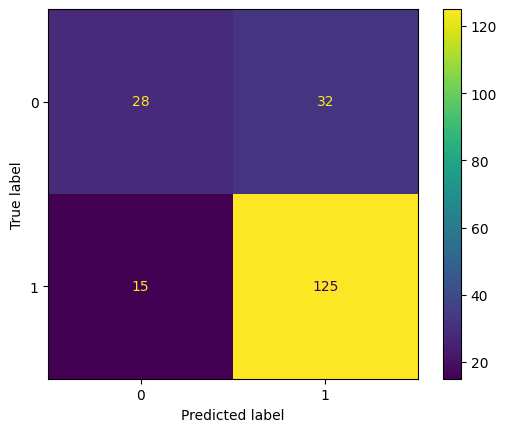

In [51]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

In [52]:
from sklearn.metrics import roc_auc_score
probabilities = rf.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test, probabilities)
print("ROC AUC:", roc_auc)

ROC AUC: 0.7719642857142855


In [53]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})
importance = importance.sort_values(
    by="Importance",
    ascending=False
)
importance

,Feature,Importance
6,Credit amount,0.247042
0,Age,0.179004
7,Duration,0.159066
5,Checking account,0.134308
8,Purpose,0.093359
4,Saving accounts,0.063835
2,Job,0.050711
3,Housing,0.040886
1,Sex,0.031788


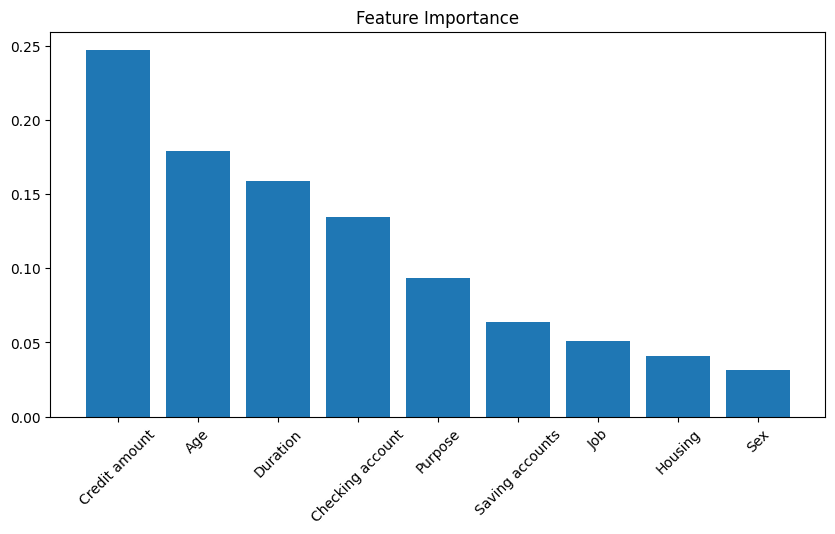

In [54]:
plt.figure(figsize=(10,5))
plt.bar(
    importance["Feature"],
    importance["Importance"]
)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

In [38]:
import joblib
joblib.dump(
    rf,
    "credit_scoring_model.pkl"
)

['credit_scoring_model.pkl']

In [39]:
sample = X.iloc[[0]]
prediction = rf.predict(sample)
print("Prediction:", prediction)

Prediction: [1]


In [55]:
!ls /kaggle/working

credit_scoring_model.pkl
